In [76]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re
import nltk
from sklearn.model_selection import train_test_split
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
import tensorflow as tf


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [77]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [78]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [80]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


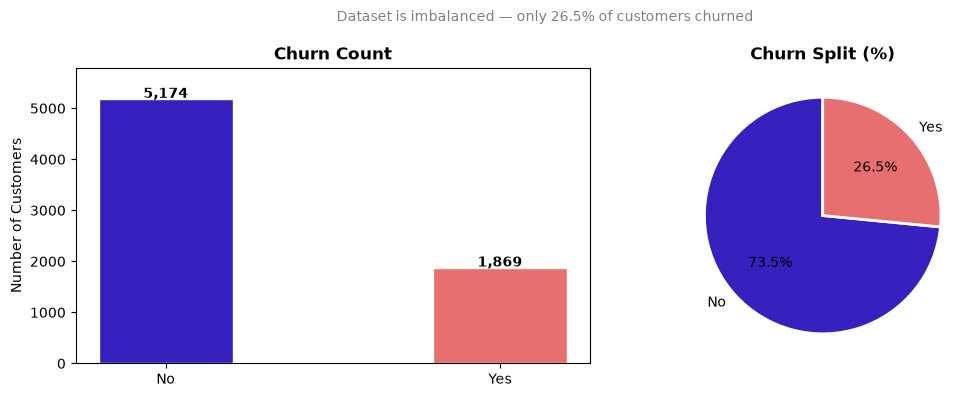

In [81]:
counts = df['Churn'].value_counts()
colors = ["#3621BE", '#E76F6F']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors,
                   width=0.4, edgecolor='white')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30, f'{val:,}',
                 ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.12)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Split (%)', fontweight='bold')

plt.suptitle('Dataset is imbalanced — only 26.5% of customers churned',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz1_churn_distribution.png', bbox_inches='tight')
plt.show()

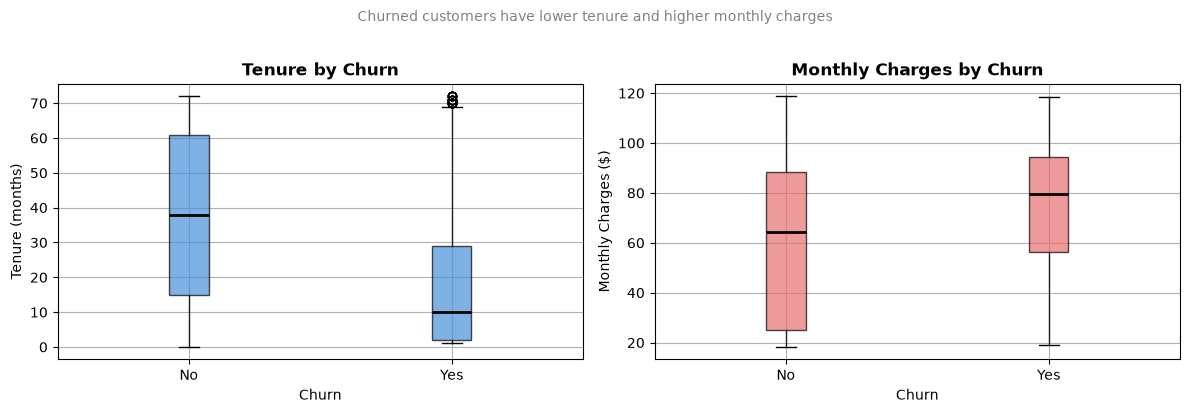

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tenure boxplot
df.boxplot(column='tenure', by='Churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#4A90D9', alpha=0.7),
           medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Tenure by Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (months)')
plt.sca(axes[0])
plt.title('Tenure by Churn', fontweight='bold')

# MonthlyCharges boxplot
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#E76F6F', alpha=0.7),
           medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')
plt.sca(axes[1])
plt.title('Monthly Charges by Churn', fontweight='bold')

plt.suptitle('Churned customers have lower tenure and higher monthly charges',
             fontsize=10, color='gray', y=1.02)
plt.tight_layout()
plt.savefig('viz2_tenure_charges.png', bbox_inches='tight')
plt.show()

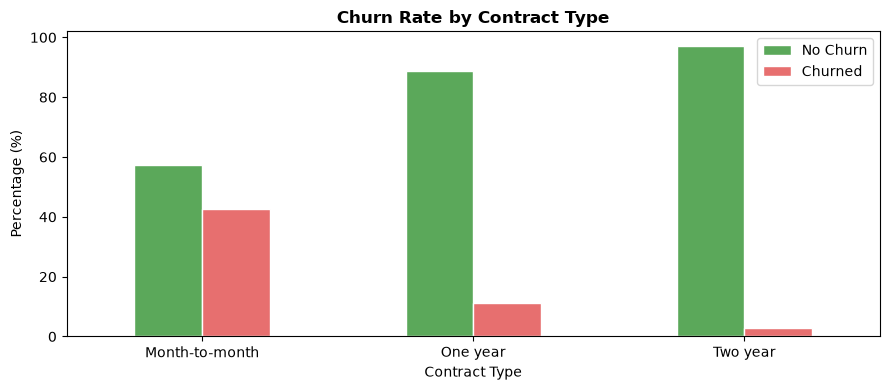

Month-to-month churn rate: 42.7%


In [83]:
contract_churn = df.groupby('Contract')['Churn']\
                   .value_counts(normalize=True)\
                   .unstack()\
                   .fillna(0) * 100

contract_churn.plot(kind='bar', color=['#5BA85A', '#E76F6F'],
                    figsize=(9, 4), edgecolor='white', width=0.5)
plt.title('Churn Rate by Contract Type', fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('viz3_contract_churn.png', bbox_inches='tight')
plt.show()

# Key insight print
month_churn = df[df['Contract']=='Month-to-month']['Churn']\
              .value_counts(normalize=True)['Yes'] * 100
print(f'Month-to-month churn rate: {month_churn:.1f}%')

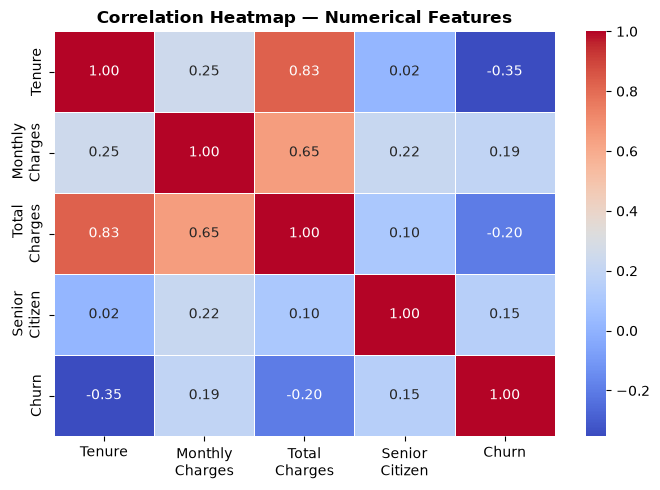

In [84]:
# Only numerical columns for correlation
num_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
# Convert TotalCharges temporarily to check correlation
temp = df.copy()
temp['TotalCharges'] = pd.to_numeric(temp['TotalCharges'], errors='coerce')
temp['Churn_num'] = (temp['Churn'] == 'Yes').astype(int)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'SeniorCitizen', 'Churn_num']

corr = temp[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, cbar=True,
            xticklabels=['Tenure','Monthly\nCharges',
                         'Total\nCharges','Senior\nCitizen','Churn'],
            yticklabels=['Tenure','Monthly\nCharges',
                         'Total\nCharges','Senior\nCitizen','Churn'])
ax.set_title('Correlation Heatmap — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [85]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
str_columns=df.select_dtypes(include=['object']).columns #object means string type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


for col in str_columns:
    df[col]=le.fit_transform(df[col])


C:\Users\nikhi\AppData\Local\Temp\ipykernel_5988\1601808555.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_columns=df.select_dtypes(include=['object']).columns #object means string type


In [86]:
# Your code encodes ALL object columns including customerID
# customerID is just an ID — it should be dropped before encoding
df.drop('customerID', axis=1, inplace=True)

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler=StandardScaler()
cluster_features=df[['tenure', 'MonthlyCharges', 'TotalCharges']]
cluster_scaled = scaler.fit_transform(cluster_features)

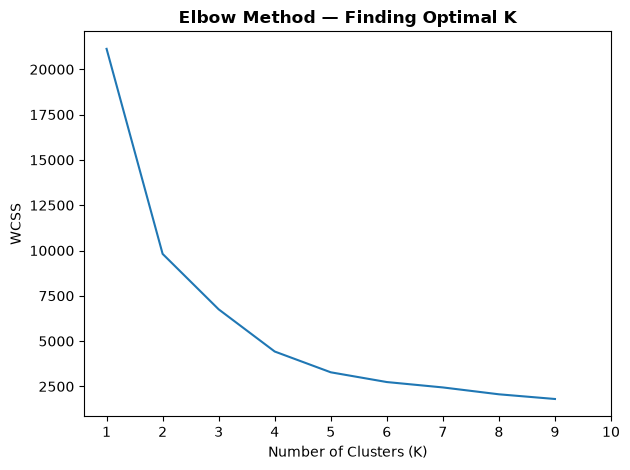

In [88]:
wcss=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,10),wcss)
plt.title('Elbow Method — Finding Optimal K', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig('viz5_elbow_curve.png', bbox_inches='tight')
plt.show()

In [89]:
kmeans1=KMeans(n_clusters=3,init='k-means++',random_state=42)
y_kmeans=kmeans1.fit_predict(cluster_scaled)
df['Cluster'] = kmeans1.fit_predict(cluster_scaled)


In [90]:
y_kmeans

array([2, 0, 2, ..., 2, 2, 1], shape=(7043,), dtype=int32)

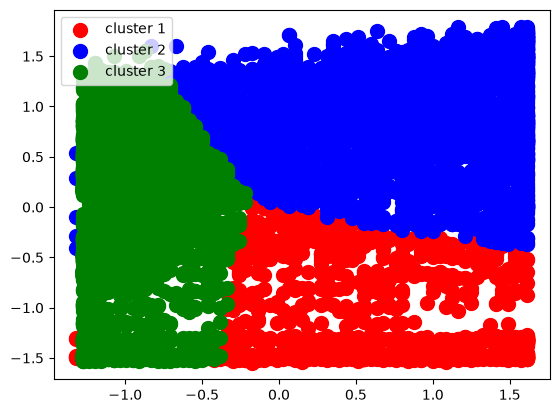

In [91]:
plt.scatter(cluster_scaled[y_kmeans==0,0],cluster_scaled[y_kmeans==0,1],s=100,c='red',label='cluster 1')
plt.scatter(cluster_scaled[y_kmeans==1,0],cluster_scaled[y_kmeans==1,1],s=100,c='blue',label='cluster 2')
plt.scatter(cluster_scaled[y_kmeans==2,0],cluster_scaled[y_kmeans==2,1],s=100,c='green',label='cluster 3')
# plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=100,c='yellow',label='centroid')
plt.legend()
plt.show()

In [92]:
print('Churn rate per cluster:')
print((df.groupby('Cluster')['Churn'].mean() * 100).round(1))
print()
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())
print()
# Average tenure and charges per cluster
print('Cluster profile:')
print(df.groupby('Cluster')[['tenure','MonthlyCharges','TotalCharges']].mean().round(1))

Churn rate per cluster:
Cluster
0     4.9
1    20.2
2    41.9
Name: Churn, dtype: float64

Cluster sizes:
Cluster
0    1315
1    2738
2    2990
Name: count, dtype: int64

Cluster profile:
         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0          47.3            31.5        2984.7
1          51.5            90.2        5133.5
2           8.3            56.1        1303.5


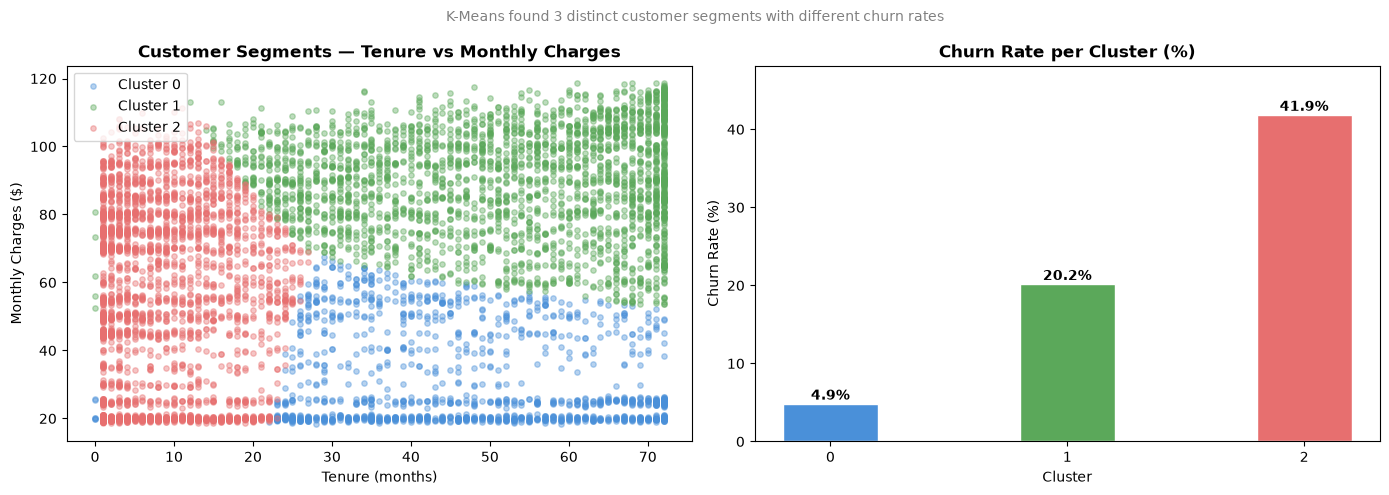

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Scatter: tenure vs MonthlyCharges colored by cluster
colors_cluster = ['#4A90D9', '#5BA85A', '#E76F6F']
for cluster in range(3):
    mask = df['Cluster'] == cluster
    axes[0].scatter(df[mask]['tenure'],
                    df[mask]['MonthlyCharges'],
                    c=colors_cluster[cluster],
                    label=f'Cluster {cluster}',
                    alpha=0.4, s=15)
axes[0].set_title('Customer Segments — Tenure vs Monthly Charges',
                  fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].legend()

# Plot 2 — Churn rate per cluster bar chart
churn_by_cluster = df.groupby('Cluster')['Churn'].mean() * 100
bars = axes[1].bar(churn_by_cluster.index,
                   churn_by_cluster.values,
                   color=colors_cluster, edgecolor='white', width=0.4)
axes[1].set_title('Churn Rate per Cluster (%)', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticks([0, 1, 2])
for bar, val in zip(bars, churn_by_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(churn_by_cluster.values) * 1.15)

plt.suptitle('K-Means found 3 distinct customer segments with different churn rates',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz6_clusters.png', bbox_inches='tight')
plt.show()

In [94]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,74,0,2
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,3624,0,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,536,1,2
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,3570,0,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,674,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,...,2,2,2,1,1,3,84.80,3700,0,1
7039,0,0,1,1,72,1,2,1,0,2,...,0,2,2,1,1,1,103.20,6304,0,1
7040,0,0,1,1,11,0,1,0,2,0,...,0,0,0,0,1,2,29.60,1265,0,2
7041,1,1,1,0,4,1,2,1,0,0,...,0,0,0,0,1,3,74.40,1157,1,2


In [95]:
X=df.drop(['Churn','Cluster'],axis=1)
y=df['Churn']

In [96]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [97]:
scaler_x=StandardScaler()
x_train=scaler_x.fit_transform(x_train)
x_test=scaler_x.transform(x_test)

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
svc=SVC(kernel='rbf',random_state=42)
log=LogisticRegression(max_iter=500,random_state=42)

In [99]:
svc.fit(x_train,y_train)
log.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [100]:

y_pred1=svc.predict(x_test)
y_pred2=svc.predict(x_test)

In [101]:
from sklearn.metrics import classification_report,accuracy_score

In [102]:
print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred2):.4f}')
print()
print(classification_report(y_test, y_pred2,
                             target_names=['No Churn', 'Churned']))


=== Logistic Regression ===
Accuracy : 0.7910

              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1298
     Churned       0.65      0.43      0.52       463

    accuracy                           0.79      1761
   macro avg       0.74      0.68      0.69      1761
weighted avg       0.78      0.79      0.78      1761



In [103]:
print('=== Support vector classifier ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred1):.4f}')
print()
print(classification_report(y_test, y_pred1,
                             target_names=['No Churn', 'Churned']))

=== Support vector classifier ===
Accuracy : 0.7910

              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1298
     Churned       0.65      0.43      0.52       463

    accuracy                           0.79      1761
   macro avg       0.74      0.68      0.69      1761
weighted avg       0.78      0.79      0.78      1761



In [104]:
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [115]:
ann = Sequential([
    Dense(units=128, activation="relu", input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(units=64, activation="relu"),
    Dropout(0.3),
    Dense(units=1, activation="sigmoid")
])

d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [116]:
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [110]:
ann.summary()

# class_weight — 26% churned vs 74% not churned
# weight ratio = 74/26 ≈ 2.8
class_weight = {0: 1.0, 1: 2.8}

early_stop = EarlyStopping(monitor='val_loss',
                            patience=3,
                            restore_best_weights=True,
                            verbose=1)

history = ann.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7288 - loss: 0.7648 - val_accuracy: 0.7675 - val_loss: 0.4942
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7475 - loss: 0.7036 - val_accuracy: 0.7164 - val_loss: 0.5375
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7492 - loss: 0.6892 - val_accuracy: 0.7637 - val_loss: 0.4746
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7536 - loss: 0.6780 - val_accuracy: 0.7864 - val_loss: 0.4515
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7597 - loss: 0.6679 - val_accuracy: 0.7788 - val_loss: 0.4624
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7669 - loss: 0.6605 - val_accuracy: 0.7618 - val_loss: 0.4569
Epoch 7/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7658 - loss: 0.6560 - val_accuracy: 0.7826 - val_loss: 0.4589
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


In [111]:
y_pred_ann_prob = ann.predict(x_test)
y_pred_ann = (y_pred_ann_prob > 0.5).astype(int).flatten()

print('=== ANN ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_ann):.4f}')
print()
print(classification_report(y_test, y_pred_ann,
                             target_names=['No Churn', 'Churned']))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== ANN ===
Accuracy : 0.7575

              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1298
     Churned       0.53      0.74      0.61       463

    accuracy                           0.76      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.80      0.76      0.77      1761



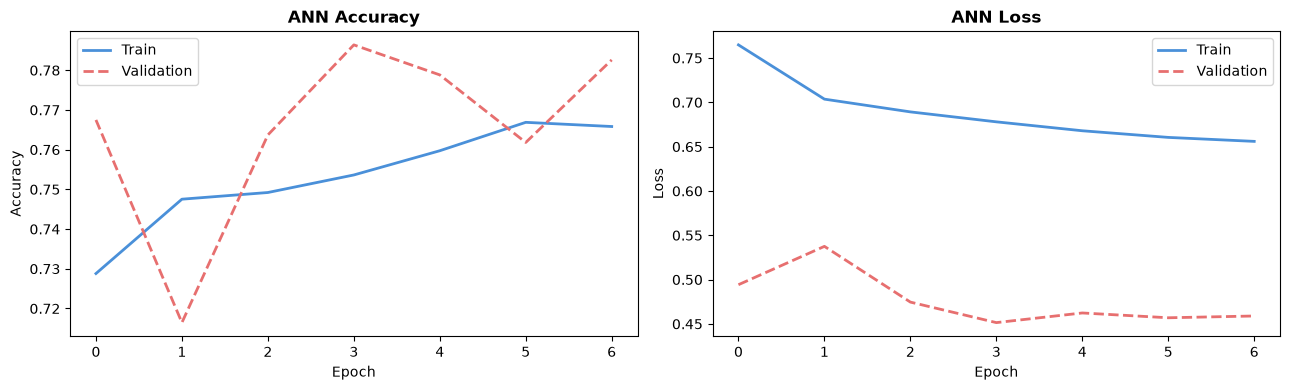

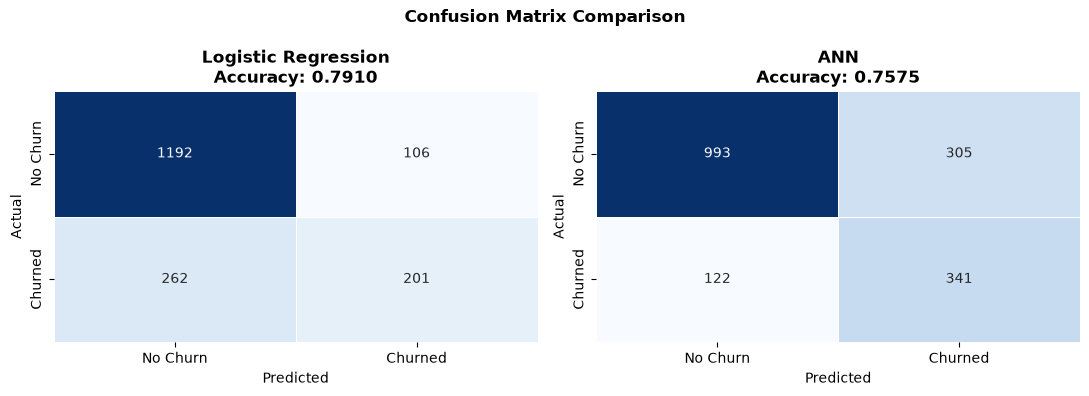

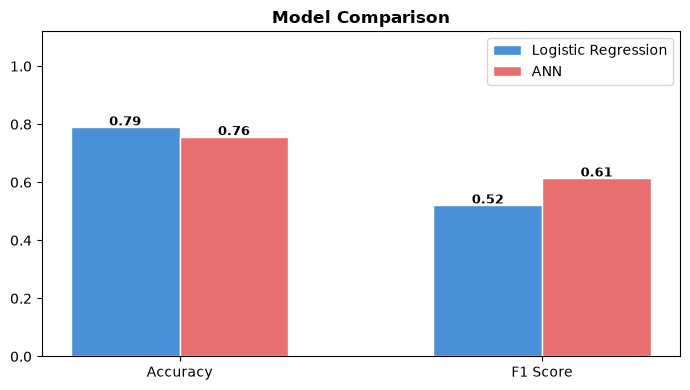

In [114]:
# Training curve
from sklearn.metrics import f1_score,confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'],
             label='Train', color='#4A90D9', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='#E76F6F',
             linewidth=2, linestyle='--')
axes[0].set_title('ANN Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],
             label='Train', color='#4A90D9', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation', color='#E76F6F',
             linewidth=2, linestyle='--')
axes[1].set_title('ANN Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('viz7_training_curve.png', bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
models = [('Logistic Regression', y_pred1),
          ('ANN',                 y_pred_ann)]
for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'],
                cbar=False, linewidths=0.5)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz8_confusion_matrices.png', bbox_inches='tight')
plt.show()

# Model comparison
metrics = ['Accuracy', 'F1 Score']
lr_scores  = [accuracy_score(y_test, y_pred1),
              f1_score(y_test, y_pred1)]
ann_scores = [accuracy_score(y_test, y_pred_ann),
              f1_score(y_test, y_pred_ann)]
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, lr_scores,  width,
               label='Logistic Regression', color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + width/2, ann_scores, width,
               label='ANN', color='#E76F6F', edgecolor='white')
for bar, val in zip(list(bars1)+list(bars2), lr_scores+ann_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz9_model_comparison.png', bbox_inches='tight')
plt.show()